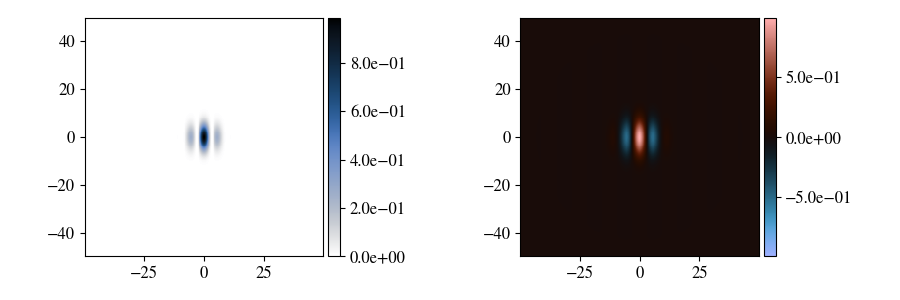

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from bloch_schrodinger.potential import create_parameter
from bloch_schrodinger.plotting import plot_eigenvector

from BECs.ssfm import SSFM
from BECs.potentialT import PotentialT
from BECs.ufuncs import gaussian2D

lx, ly = 100, 100

potential = PotentialT(
    unitvecs=[[lx,0],[0,ly]],
    resolution = (256,256),
    v0 = 0
)

alpha = 0.5
g = 0
k = create_parameter("k", np.linspace(0.5, 1.5, 3))

psi0 = gaussian2D(potential.x, potential.y, 0, 0, 5, 5, 1) * np.cos(k*potential.x)

%matplotlib widget
plot_eigenvector(
    [[abs(psi0)**2,psi0.real]],
    [[potential, potential]],
    [['amplitude', 'real']]
)
plt.show()

we can let this wavepacket evolve freely, simulating it with the `SSFM` class

In [10]:
free = SSFM(
    potential,
    psi0,
    alpha,
    g
)

ti, tf = 0, 100
t_samples = create_parameter('t', np.linspace(ti,tf,201))

free_evolution = free.solve(ti, tf, t_samples, parallelize=True, n_cores = 3, dtmax = 10, tol = 1e-4)

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   19.0s finished


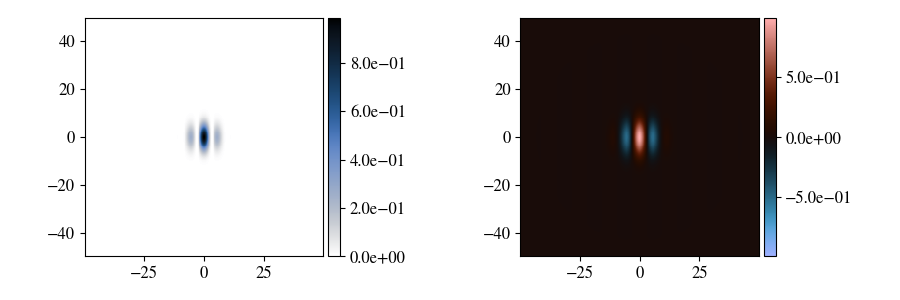

In [11]:
plot_eigenvector(
    [[abs(free_evolution)**2,free_evolution.real]],
    [[potential, potential]],
    [['amplitude', 'real']]
)
plt.show()

We can see the classic separation of the sum of gaussian wavepackets into two counter-propagating parts. Now, instead of this free evolution, let's perform this evolution in an harmonic trap of frequency $\omega$:

In [12]:
T = 100 # trap period
omega = 2 * np.pi / T

potential.set((potential.x**2+potential.y**2) * omega**2 / 2)

trapped = SSFM(
    potential,
    psi0,
    alpha,
    g
)

harmonic_evolution = trapped.solve(ti, tf, t_samples, parallelize=True, n_cores = 3, dtmax = 10, verbose = True, tol = 1e-4)

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   1 tasks      | elapsed:   17.3s
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   17.8s finished


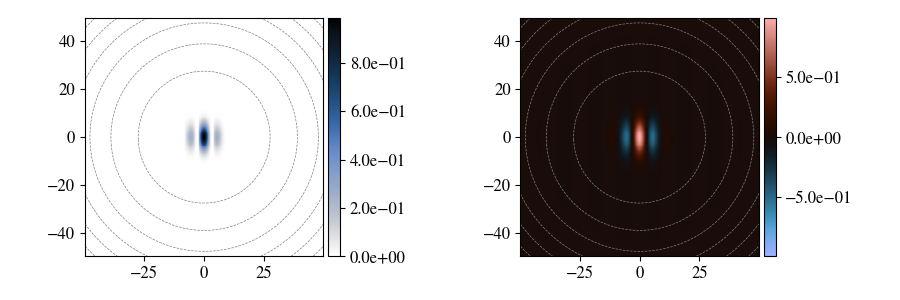

In [13]:
plot_eigenvector(
    [[abs(harmonic_evolution)**2,harmonic_evolution.real]],
    [[potential, potential]],
    [['amplitude', 'real']]
)
plt.show()

Looking at this evolution, we notice two important times, $t = T/4 + nT$ and $t = T/2 + nT$ with $n \in \mathbb{N}$. When $t = T/4$, the wavepacket kinetic energy $\propto k^2$ as been totally converted to potential energy, and because we are in an harmonic trap, its distance $\bf{r} = \braket{\psi|\hat{\bf{r}}|\psi}$ is proportional to $\bf{k}$. More generally, we can say that the wavefunction at $t = T/4$ is equal to the Fourier transform of $\psi(t = 0)$, thus, a quarter-period evolution in an harmonic potential corresponds to the propagation of a EM-field between the object and Fourier plane of a lense. Our second observation follows from the first, as a second $T/4$ evolution transforms back the wavefunction to its initial condition, with a $\pi$ phaseshift.

With these observations made, it is easy to see how this can be used to create 'optical-like' imaging set-up, by combining multiple harmonic trap evolutions. Let's for example build a simple telescope with a magnification of 2. To do so, we just have to perform two $T/4$ evolutions, the first in a trap of frequency $\omega$, the second in a trap of frequency $\omega / 2$. We can easily implement that with the `PotentialT` class.

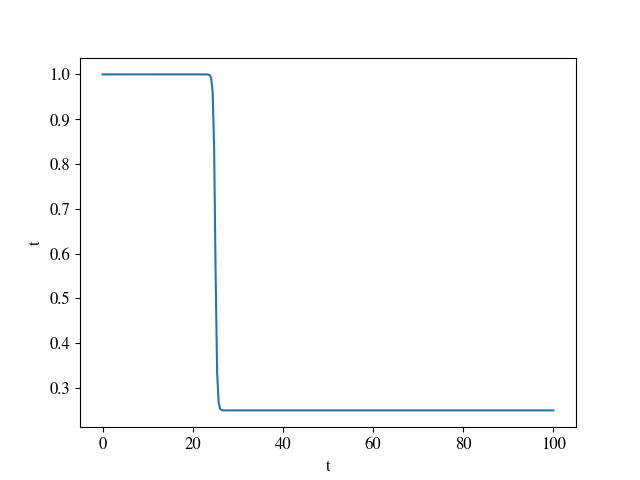

In [14]:
potential.clear()

potential.add_shape("trap", (potential.x**2 + potential.y**2)*omega**2/2) # We add an harmonic trap to the time-dependant shape manager
potential.step("stepdown", T/4, 1, 1,0.25) # We add a smooth step function to the time function manager

potential.plot_timefunction('stepdown', ti, tf, 300) # Let's look at the time function
plt.show()

In [15]:
potential.add_term("trap * stepdown")

telescope = SSFM(
    potential,
    psi0,
    alpha,
    g
)

telescope_evolution = telescope.solve(ti, tf, t_samples, parallelize=True, n_cores = 3, dtmax = 10, verbose = True, tol = 1e-4)

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


ValueError: operands could not be broadcast together with shapes (0,0) (256,256) 

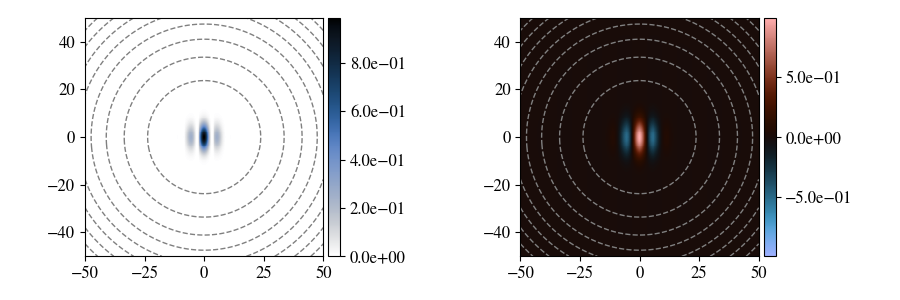

In [ ]:
from bloch_schrodinger.plotting import contour_tmpl

tmpl = contour_tmpl()
tmpl['fkwargs']["levels"] = np.linspace(0, 10, 10)
tmpl['fkwargs']["colors"] = 'gray'


potential_arr = potential.to_potential(t_coord = t_samples)

plot_eigenvector(
    [[abs(telescope_evolution)**2, telescope_evolution.real]],
    [[potential_arr, potential_arr]],
    [[('amplitude', tmpl), ('real', tmpl)]]
)
plt.show()

In this evolution, we can see that at $t = T/4 + T/2 = 75$, we recover the same pattern that exists at $t = 0$, magnified by a factor of $-2$, independantly of the initial value for $k$.

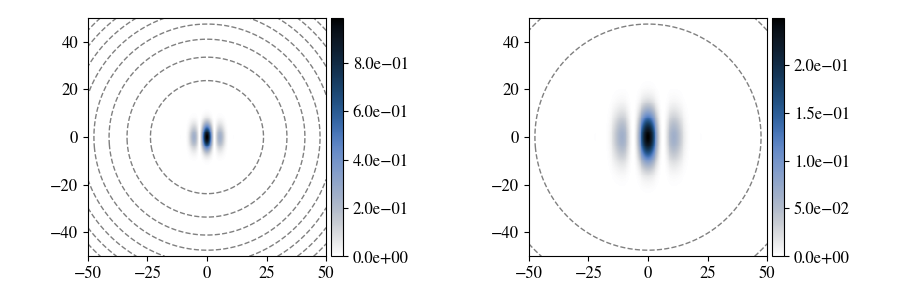

In [ ]:
plot_eigenvector(
    [[abs(telescope_evolution.sel(t = 0))**2, abs(telescope_evolution.sel(t = T/4 + T/2, method = 'nearest'))**2]],
    [[potential.to_potential(t = 0), potential.to_potential(t = T/4 + T/2)]],
    [[temp_amp, temp_amp]]
)
plt.show()

Perfectly tuning a transition between two values of trapping frequency can be challenging, but the same kind of magnification technique can be performed with a $T/4 + \epsilon$ harmonic trap evolution, before performing a time-of-flight measurement. The magnification obtained by this method scales with $~ 1/\epsilon$, which allow to resolve tiny details of an atomic cloud, which would otherwise require very high aperture optical set-up [[1]](https://www.nature.com/articles/s41586-021-04011-2).

Of course, magnifying gaussian wavepacket is rather boring, but the same exact method can be used to image more complex condensate, or even combined with other optical techniques, such as phase-contrast imaging, this is what we are going to present in the next part of this tutorial.

## A phase microscope for quantum gases

Here, we propose to perform some simple simulations to demonstrate the principles behind the experiments shown in [[J. C. Brüggenjürgen et al.]](https://arxiv.org/pdf/2410.10611).

### Lattice simulation

Before describing the phase microscope, let's perform a characterization of the honeycomb lattice studied. We are going to compute its linear eigenvector and band structure using the `bloch_schrodinger package`.

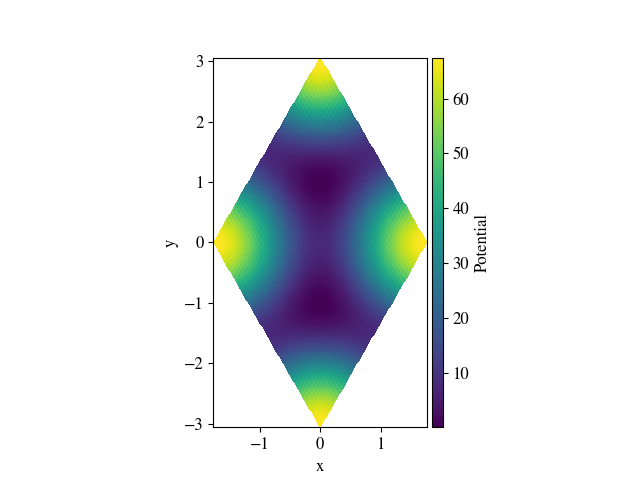

In [ ]:
from bloch_schrodinger.potential import Potential
from bloch_schrodinger.solver import Solver

lamb = 3 # The linewidth of the laser beams
a = lamb * 2 / 3
a1 = np.array([-(3**0.5) / 2 * a, 3 / 2 * a])  # 1st lattice vector
a2 = np.array([3**0.5 / 2 * a, 3 / 2 * a])  # 2nd lattice vector

unitcell = Potential(
    unitvecs=[a1, a2], resolution=(50,50), v0 = 0
)

# The lattice is created by the intersection of three standing wave beams rotated by 120°
intensity = 30
dirs = [np.cos(theta) * (unitcell.x-a1[0]) + np.sin(theta) * unitcell.y for theta in [np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3]]

for dir in dirs:
    unitcell.add(value= intensity * np.cos(dir * np.pi / lamb)**2 - intensity/4)

unitcell.plot()
plt.show()

In [ ]:
solv = Solver(
    unitcell, alpha, 
)

solv.create_reciprocal_grid(kx = np.linspace(-2, 2, 49), ky = np.linspace(-2, 2, 11)) # reduced  grid size for quick diagonalization
eigva, eigve = solv.parallel_solve(n_eigva = 2, n_cores = -1)

Creating Hamiltonians


100%|██████████| 539/539 [00:02<00:00, 208.12it/s]


Performing the diagonalization...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 539 out of 539 | elapsed:    8.6s finished


storing the results


100%|██████████| 539/539 [00:00<00:00, 872.80it/s]


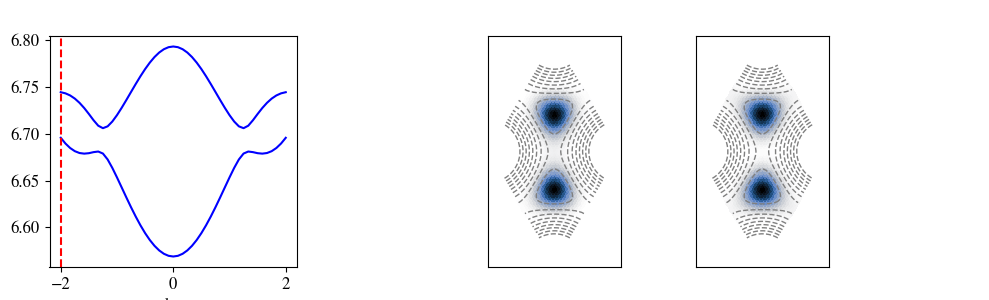

In [ ]:
from bloch_schrodinger.plotting import dashboard

temp_amp2 = get_template('amplitude')
temp_amp2['contourkwargs']["levels"] = np.linspace(0, 40, 10)
temp_amp2['contourkwargs']["colors"] = 'gray'

dashboard(eigva, 'kx', [[abs(eigve.sel(band=1)**2), abs(eigve.sel(band=0))**2]], unitcell, temp_amp2, gskw={'wspace':-0.5})
plt.show()

We recognize the canonical band structure and eigenvectors of the honeycomb lattice and can clearly see the Dirac cones at the $K$ and $K'$ points, where $k = 4\pi/3 \sqrt{3} a \approx 3.41$. Now, let's simulate a much larger lattice and see what kind of measurement we can perform using matter-wave optics.

### Finding the ground state of a large lattice

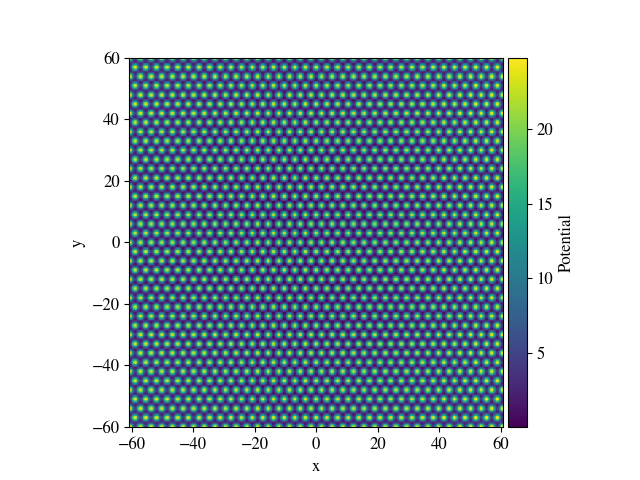

In [ ]:
%reload_ext autoreload
%autoreload 2

lx = 70 * a2[0]
ly = 40 * a1[1]

lattice = PotentialT(
    unitvecs=[[lx,0],[0,ly]], resolution=(512,512), v0 = 0
)
plt.close('all')


intensity = 10
dirs = [np.cos(theta) * (lattice.x-a1[0]) + np.sin(theta) * lattice.y for theta in [np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3]]
lat_pot = 0
for dir in dirs:
    lat_pot += intensity * np.cos(dir * np.pi / lamb)**2 - intensity/4
lattice.set(lat_pot)

lattice.add((lattice.x**2 + lattice.y**2)/2 * 0.025**2)

lattice.plot()
plt.show()

In [ ]:
from BECs.groundstate import GroundStateSSFM
latticeGround = GroundStateSSFM(
    lattice, alpha, g
)
energy, groundstate = latticeGround.solve(population=1, tol_adapt = 1e-4, tol_stop=1e-5)

Computing the ground states


100%|██████████| 1/1 [00:35<00:00, 35.47s/it]


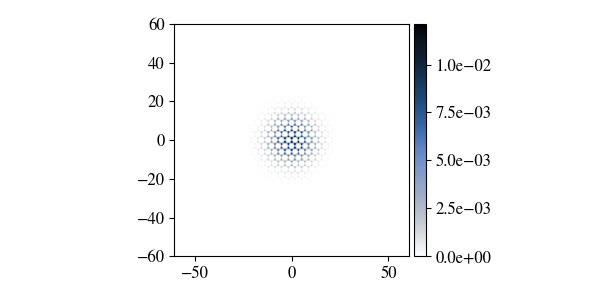

In [ ]:
plot_eigenvector(
    [[abs(groundstate)**2]],
    [[lattice]],
    [['amplitude']]
)
plt.show()

As expected from the eigenvector computations, the ground state of the lattice is a bonding mode with equal weigth on both sublattices. Let's now release this condensate and demonstrate the quantum microscopy set-up.

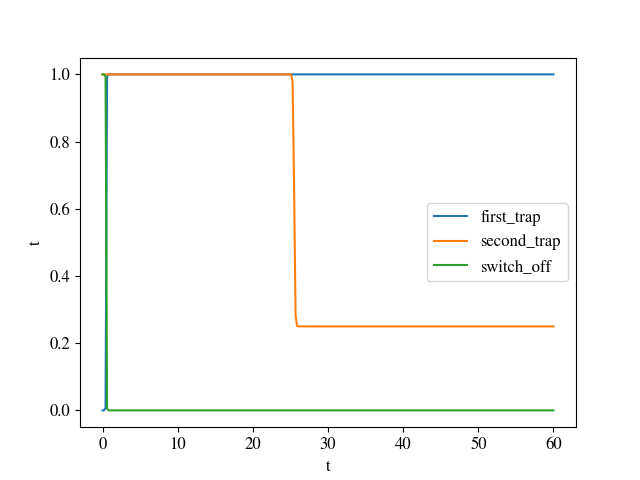

In [ ]:
T = 100
omega = 2*np.pi/T

lattice.set(lat_pot)

lattice.step("first_trap", 0.5, 0.1, 0, 1)
lattice.step("second_trap", T/4 + 0.5, 0.3, 1, 0.25)
lattice.step("switch_off", 0.5, 0.1, 1, 0)

lattice.plot_timefunction(["first_trap", "second_trap", "switch_off"], 0, 60, 300)
plt.show()

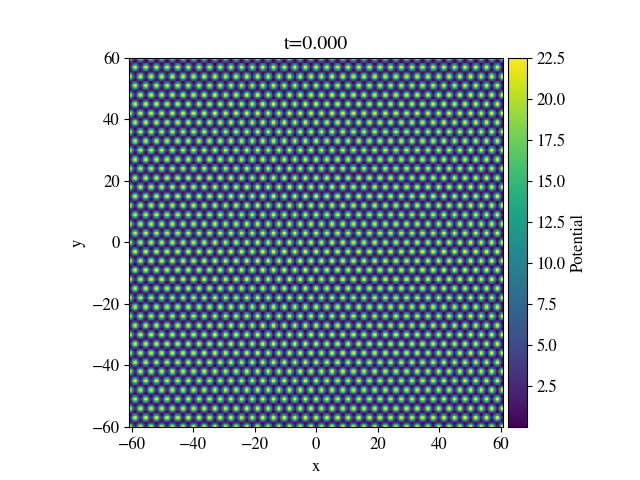

In [ ]:
lattice.add_shape("trap", (lattice.x**2+lattice.y**2)/2 * omega**2)

lattice.modulate("switch_off")
lattice.add_term("trap * first_trap * second_trap")

lattice.plot_t(0, 60, 100)
plt.show()

In [ ]:
from BECs.ufuncs import gaussian2D

telescope_lattice = SSFM(
    lattice,
    groundstate,
    alpha,
    g
)

ti, tf = 0, 80
t_samples = create_parameter('t', np.linspace(ti,tf,161))


lattice_evolution = telescope_lattice.solve(ti, tf, t_samples, parallelize=False, dtmax = 10, verbose = True, tol = 1e-8)
# The lattice switch off takes more time to compute because of the fast potential changes, we are also running a very large grid, which should take a few minutes

Propagating the initial states. 1 iterations to perform


 99%|█████████▉| 79.033/80,  1.43s/it, [01:52 < 00:01]   


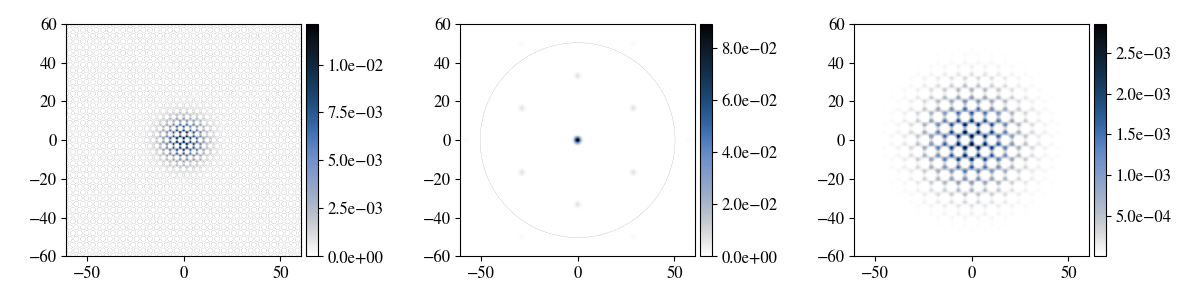

In [ ]:
temp_amp2["contourkwargs"]["levels"] = [5]
temp_amp2["contourkwargs"]["linewidths"] = 0.2

plot_eigenvector(
    [[abs(lattice_evolution)**2, abs(lattice_evolution.sel(t = 25))**2, abs(lattice_evolution.sel(t = 75.5))**2]],
    [[lattice.to_potential(t_coord = t_samples), lattice.to_potential(t = 25), lattice.to_potential(t = 75.5)]],
    [[temp_amp2, temp_amp2, temp_amp2]]
)
plt.show()

Thanks to a matter-wave microscope, we have obtained at the end an atomic cloud twice as large as the itinial one. This offers many possibilities, from the resolution of sublattice features to, as we will see in the next part, phase measurements methods.

### A quantum gas phase contrast imaging

In optics, phase-contrast microscopy is a technique that converts phase shifts occuring in a transmitted medium to brightness changes in the image. This is achieved by applying a phaseshift to the $k = 0$ component of the light beam in the Fourier plane. Here, we can use this technique by simply applying at $t = T/4$ a $\pi/4$ phaseshift at the bottom of the well, which corresponds to the $k=0$ component of the wavefunction. To illustrate this technique, that was performed experimentally [here](https://arxiv.org/pdf/2410.10611) to study the spatial phase fluctuations of a cold-atom BEC.

In this tutorial, we will simulate these fluctuations by adding artificially a random phase-fluctuating pattern to the `groundstate`, before performing the same protocol as before, with the added contribution of a $T_p / 4$ pulse at $t = T/4$.

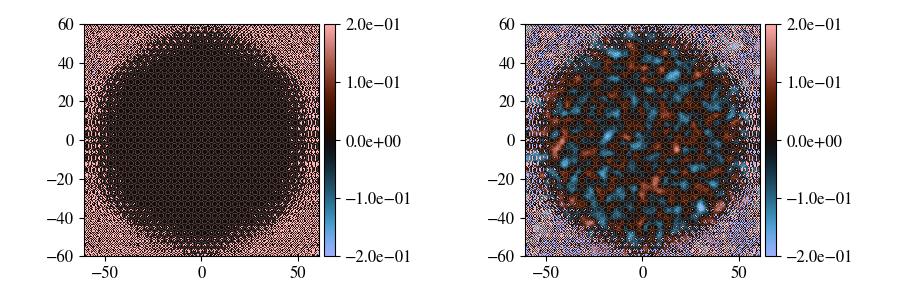

In [ ]:
# Creating the phase fluctuation pattern
from numpy.random import normal
from scipy.ndimage import gaussian_filter

flucts = gaussian_filter(normal(size = (512,512)), sigma = 6) # Correlated gaussian noise is created by blurring a random gaussian white noise
flucts_amp = 1

groundstate_fluct = groundstate * np.exp(1j*flucts*flucts_amp)

temp_phase = get_template('real')
temp_phase["contourkwargs"]["levels"] = [5]
temp_phase["contourkwargs"]["linewidths"] = 0.2
temp_phase["clim"] = (-0.2, 0.2)
temp_phase["autoscale"] = False # Don't rescale the colormap

plot_eigenvector( # We can observe the applied phase fluctuations
    [[xr.ufuncs.angle(-groundstate), xr.ufuncs.angle(-groundstate_fluct)]],
    [[lattice.to_potential(t = 0), lattice.to_potential(t = 0)]],
    [[temp_phase, temp_phase]]
)
plt.show()

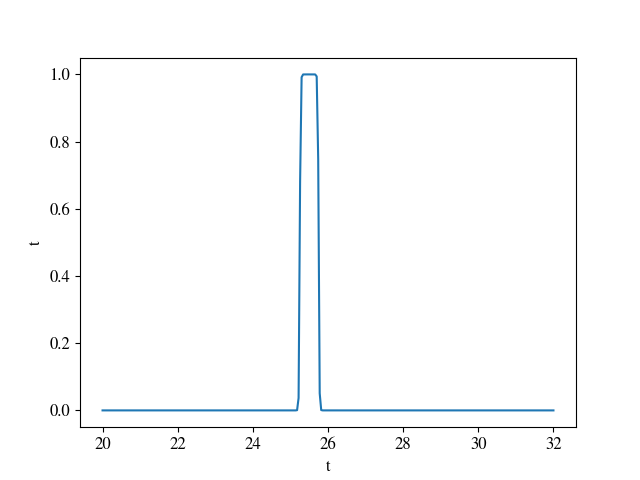

In [ ]:
# We can apply the pi/2 phase shift neccessary to the phase-contrast imaging by simply adding a term to the time-dependent potential

applied_phase = np.pi/2
pulse_duration = 0.5
pulse_amp = applied_phase / pulse_duration

lattice.circle_t(
    "pulse_shape", 
    center = (0,0),
    radius = 8,
    value = pulse_amp
)

lattice.square(
    "pulse", 
    ti = T/4 + 0.5 - pulse_duration/2, # We are in k-space at t = T/4 + 0.5
    tf = T/4 + 0.5 + pulse_duration/2, 
    sigma = 0.05, vi = 0, vf = 1
)

lattice.plot_timefunction("pulse", 20, 32, 300)
plt.show()

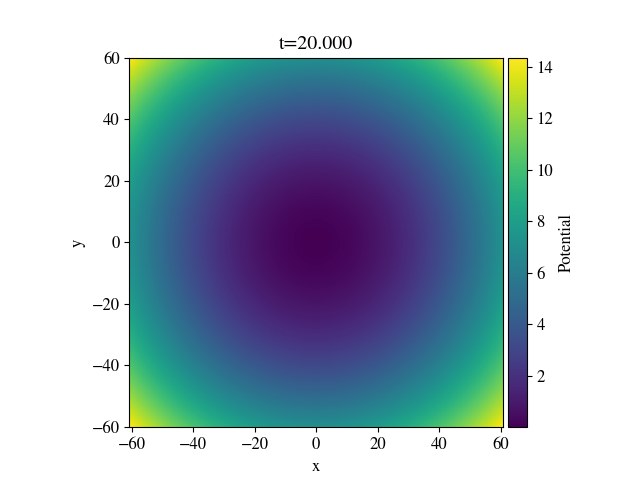

In [ ]:
lattice.add_term("pulse * pulse_shape")

lattice.plot_t(20, 30, 300)
plt.show()

In [ ]:
phasecontrast = SSFM(
    lattice,
    groundstate_fluct,
    alpha,
    g
)

ti, tf = 0, 80
t_samples = create_parameter('t', np.linspace(ti,tf,161))


psi_flucts = phasecontrast.solve(ti, tf, t_samples, parallelize=False, dtmax = 10, verbose = True, tol = 1e-8)


Propagating the initial states. 1 iterations to perform


  0%|          | 0.000/80, ?it/s, [00:00 < ?]C:\Users\marti\OneDrive\Documents\MyLibraries\BECs\BECs\potentialT.py:225: RuntimeWarning: overflow encountered in exp
  return vi + (vf - vi) * (1 / (1 + np.exp(-steep * (t - ti))) - 1 / (1 + np.exp(-steep * (t - tf))))
 99%|█████████▉| 79.277/80,  1.61s/it, [02:07 < 00:01]   


c:\Users\marti\miniconda3\envs\bloch-env\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
c:\Users\marti\miniconda3\envs\bloch-env\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


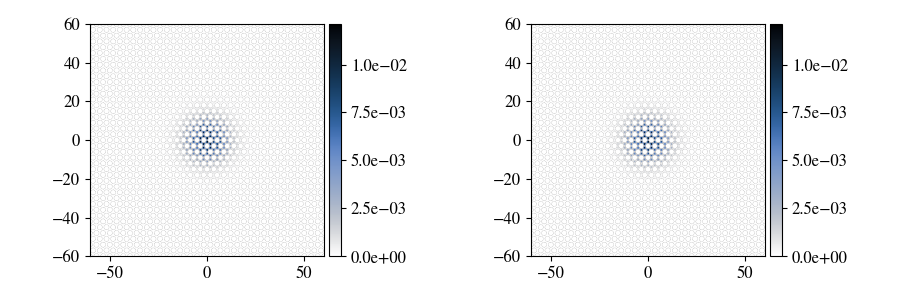

In [ ]:
plot_eigenvector(
    [[abs(lattice_evolution)**2, abs(psi_flucts)**2]],
    [[lattice.to_potential(t_coord = t_samples), lattice.to_potential(t_coord = t_samples)]],
    [[temp_amp2, temp_amp2]]
)
plt.show()

c:\Users\marti\miniconda3\envs\bloch-env\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


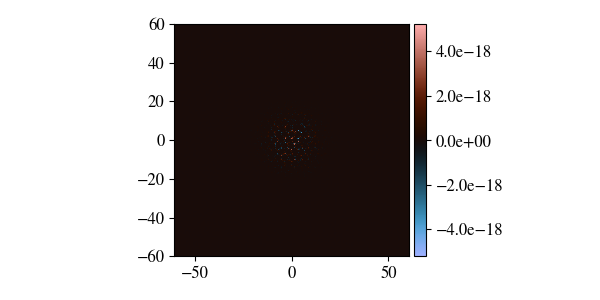

In [ ]:
plot_eigenvector(
    [[abs(lattice_evolution)**2 - abs(psi_flucts)**2]],
    [[lattice.to_potential(t_coord = t_samples)]],
    [['real']]
)
plt.show()